# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
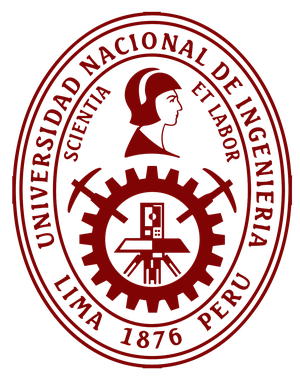
---

### Curso: Minería de Datos (CC442A)
### PC N°01: Condicionamiento Espectral y Estabilidad Numérica en el Preprocesamiento
---
---

### **Profesor:** Dr. Marco Antonio Alania Vicente
### **Estudiante:** César Omar López Arteaga

---
---

### 1. Introducción
El preprocesamiento de datos no es una mera limpieza empírica, sino un operador de transformación que actúa sobre el espectro de la matriz de datos $X \in \mathbb{R}^{n \times d}$. El dataset mal condicionado introduce inestabilidad, por lo que el objetivo de esta tarea es asegurar una matriz óptima algebraica y probabilísticamente.

### 2. Carga de Datos y Prevención de Data Leakage
Se carga el dataset de Arrhythmia.

El link del repositorio es: https://archive.ics.uci.edu/dataset/5/arrhythmia

Esta base de datos contiene 279 atributos, 206 de los cuales son de valores lineales y el resto nominales. 

Sobre el estudio de H. Altay Guvenir: "El objetivo es distinguir entre la presencia y ausencia de arritmias cardíacas y clasificarla en uno de los 16 grupos. La clase 01 se refiere a las clases de ECG 'normales' del 02 al 15, a diferentes clases de arritmia y la clase 16 al resto de las no clasificadas. Por el momento, existe un programa informático que realiza dicha clasificación. Sin embargo, existen diferencias entre la clasificación del cardiolog y el programa. Tomando los cardiologs como estándar de oro, buscamos minimizar esta diferencia mediante herramientas de aprendizaje automático."

# ¿Qué es una arritmia?

Una **arritmia** es una alteración en la generación o en la conducción de los impulsos eléctricos del corazón, que puede producir cambios en la **frecuencia**, el **ritmo** o la **secuencia de activación cardíaca**.

El principal procedimiento utilizado para estudiar estas alteraciones es el **electrocardiograma (ECG)**, el cual registra la actividad eléctrica del corazón mediante diferentes derivaciones o canales.

Entre las alteraciones del ritmo cardíaco más conocidas se encuentran:

- **Taquicardia:** frecuencia cardíaca anormalmente elevada. En un adulto en reposo suele considerarse taquicardia una frecuencia superior a aproximadamente 100 latidos por minuto.

- **Bradicardia:** frecuencia cardíaca inferior a aproximadamente 60 latidos por minuto en un adulto en reposo.

- **Latidos prematuros:** aparecen cuando una contracción cardíaca ocurre antes de lo esperado dentro del ciclo normal. Pueden ser, por ejemplo, contracciones ventriculares prematuras o supraventriculares.

- **Fibrilación o flutter auricular:** alteraciones de la actividad eléctrica de las aurículas que pueden producir un ritmo irregular o excesivamente rápido.

- **Bloqueos de conducción:** ocurren cuando el impulso eléctrico presenta dificultades para propagarse normalmente a través del corazón. Entre ellos se encuentran los bloqueos auriculoventriculares y los bloqueos de rama derecha o izquierda.

---
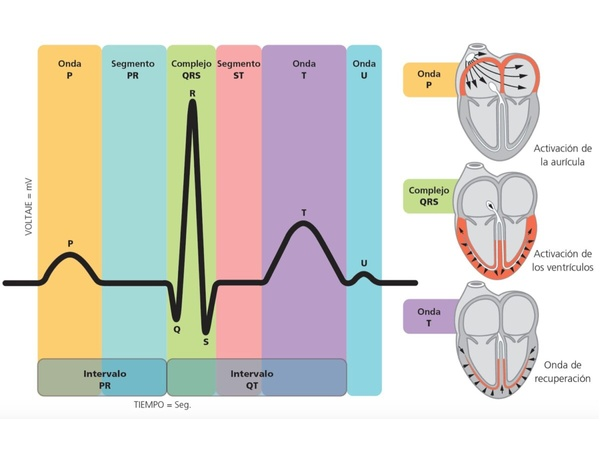

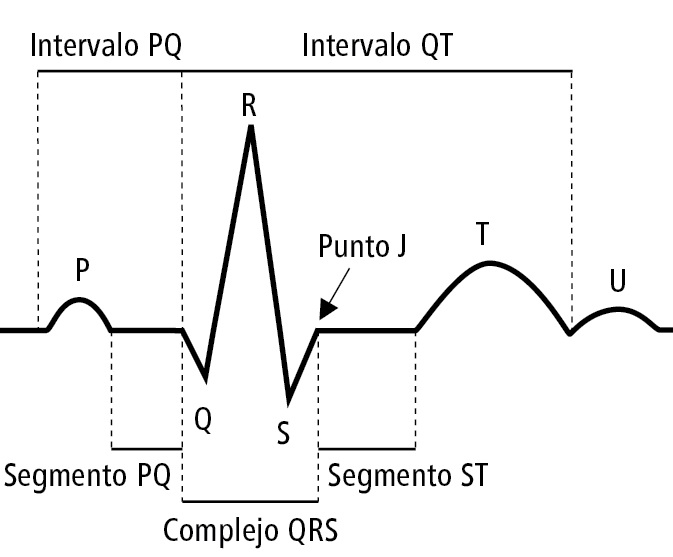


---

## Variables relevantes para el estudio de una arritmia

Una arritmia no se identifica únicamente observando la frecuencia cardíaca. El diagnóstico depende de diversas características extraídas del **electrocardiograma**, principalmente de la duración, amplitud, orientación y morfología de sus ondas.

Las principales variables consideradas en este dataset son:

### 1. Frecuencia cardíaca

La variable **Heart Rate** representa el número de latidos del corazón por minuto:

$$
HR = \text{número de latidos por minuto}.
$$

Esta variable permite identificar directamente comportamientos asociados a taquicardia o bradicardia.

---

### 2. Duración del complejo QRS

El **complejo QRS** representa principalmente la despolarización eléctrica de los ventrículos.

El dataset contiene la variable:

$$
\text{QRS duration}
$$

medida en milisegundos.

Una modificación importante de su duración puede estar asociada a alteraciones en la conducción ventricular, como los bloqueos de rama.

---

### 3. Intervalo P-R

El intervalo **P-R** mide aproximadamente el tiempo transcurrido desde el inicio de la activación eléctrica de las aurículas hasta el inicio de la activación ventricular.

En el dataset aparece como:

$$
\text{P-R interval}.
$$

Cambios en este intervalo pueden proporcionar información sobre problemas de conducción auriculoventricular.

---

### 4. Intervalo Q-T

El intervalo **Q-T** representa el tiempo comprendido entre el comienzo de la despolarización ventricular y el final de la repolarización ventricular.

El dataset contiene:

$$
\text{Q-T interval}.
$$

Por tanto, esta variable resume una parte importante de la actividad eléctrica ventricular.

---

### 5. Duración de las ondas P y T

También se registran las duraciones promedio de:

- **P interval:** duración de la onda P.
- **T interval:** duración de la onda T.

La onda **P** está relacionada principalmente con la despolarización auricular, mientras que la onda **T** está asociada con la repolarización ventricular.

---

### 6. Ángulos de los vectores eléctricos

La base de datos contiene los ángulos, medidos en grados sobre el plano frontal, correspondientes a:

$$
QRS,\quad T,\quad P,\quad QRST,\quad J.
$$

Estas variables describen la **dirección predominante de la actividad eléctrica del corazón**.

Por ejemplo, el ángulo del vector QRS proporciona información sobre la orientación global de la despolarización ventricular.

---

### 7. Morfología de las ondas del ECG

Para cada derivación se estudian características de diferentes componentes del electrocardiograma:

$$
Q,\quad R,\quad S,\quad R',\quad S',\quad P,\quad T.
$$

Entre las características registradas se encuentran:

- ancho de las ondas;
- amplitud de las ondas;
- existencia de ondas irregulares (*ragged*);
- existencia de ondas bifásicas;
- número de deflexiones intrínsecas.

Estas características permiten describir con mayor detalle la **forma del electrocardiograma**.

---

### 8. Derivaciones electrocardiográficas

Las mediciones anteriores no se realizan en un único punto del corazón. El dataset considera las 12 derivaciones electrocardiográficas:

$$
DI,\; DII,\; DIII,\; aVR,\; aVL,\; aVF,\; V1,\;V2,\;V3,\;V4,\;V5,\;V6.
$$

Cada derivación observa la actividad eléctrica cardíaca desde una orientación diferente.

Por esta razón, una misma onda puede presentar diferentes amplitudes y formas dependiendo del canal desde el cual sea observada.

---

### 9. Áreas QRSA y QRSTA

Además de las amplitudes individuales, el dataset contiene variables que resumen el área de determinados segmentos del electrocardiograma:

- **QRSA:** área asociada a los segmentos del complejo QRS.
- **QRSTA:** extensión de QRSA incorporando información de la onda T.

Estas variables proporcionan una medida adicional de la geometría de la señal eléctrica.

---



## Estructura del dataset

La base de datos utilizada corresponde a **Cardiac Arrhythmia Database** y contiene:

$$
\boxed{452\text{ pacientes}}
$$

descritos inicialmente mediante:

$$
\boxed{279\text{ atributos}}
$$

de los cuales existen variables continuas y variables nominales. La variable objetivo se encuentra dividida en **16 clases**. 

Por tanto, cada paciente puede representarse matemáticamente mediante un vector de características

$$
\mathbf{x}_i =
(x_{i1},x_{i2},\ldots,x_{i279})
\in\mathbb{R}^{279},
$$

junto con una etiqueta de clase

$$
y_i\in\{1,2,\ldots,16\}.
$$

De esta manera, inicialmente podemos representar el problema mediante una matriz de datos

$$
X\in\mathbb{R}^{452\times279},
$$

y un vector de etiquetas

$$
\mathbf{y}\in\{1,\ldots,16\}^{452}.
$$

### Descripción de las variables del dataset Arrhythmia

| Variable | Significado | Interpretación / valores |
|---|---|---|
| `age` (1) | Edad | Edad del paciente en años |
| `sex` (2) | Sexo | `0` = hombre, `1` = mujer |
| `height` (3) | Altura | Altura del paciente en centímetros |
| `weight` (4) | Peso | Peso del paciente en kilogramos |
| `qrs_duration` (5) | Duración QRS | Duración promedio del complejo QRS en milisegundos |
| `pr_interval` (6) | Intervalo P-R | Tiempo promedio entre el inicio de las ondas P y Q, en ms |
| `qt_interval` (7) | Intervalo Q-T | Tiempo promedio entre el inicio de Q y el final de T, en ms |
| `t_interval` (8) | Duración de onda T | Duración promedio de la onda T, en ms |
| `p_interval` (9) | Duración de onda P | Duración promedio de la onda P, en ms |
| `qrs_angle` (10) | Ángulo QRS | Ángulo del vector QRS en el plano frontal, en grados |
| `t_angle` (11) | Ángulo T | Ángulo del vector de la onda T, en grados |
| `p_angle` (12) | Ángulo P | Ángulo del vector de la onda P, en grados |
| `qrst_angle` (13) | Ángulo QRST | Ángulo del vector QRST en el plano frontal |
| `j_angle` (14) | Ángulo J | Ángulo del vector J en el plano frontal |
| `heart_rate` (15) | Frecuencia cardíaca | Número de latidos del corazón por minuto |
| `Variable_16` – `Variable_27` | Características de la derivación DI | Anchuras de Q, R, S, R', S'; número de deflexiones intrínsecas y características morfológicas de las ondas R, P y T |
| `Variable_28` – `Variable_39` | Características de la derivación DII | Mismas 12 características de forma y anchura medidas en DII |
| `Variable_40` – `Variable_51` | Características de la derivación DIII | Mismas 12 características medidas en DIII |
| `Variable_52` – `Variable_63` | Características de la derivación AVR | Mismas 12 características medidas en AVR |
| `Variable_64` – `Variable_75` | Características de la derivación AVL | Mismas 12 características medidas en AVL |
| `Variable_76` – `Variable_87` | Características de la derivación AVF | Mismas 12 características medidas en AVF |
| `Variable_88` – `Variable_99` | Características de la derivación V1 | Mismas 12 características medidas en V1 |
| `Variable_100` – `Variable_111` | Características de la derivación V2 | Mismas 12 características medidas en V2 |
| `Variable_112` – `Variable_123` | Características de la derivación V3 | Mismas 12 características medidas en V3 |
| `Variable_124` – `Variable_135` | Características de la derivación V4 | Mismas 12 características medidas en V4 |
| `Variable_136` – `Variable_147` | Características de la derivación V5 | Mismas 12 características medidas en V5 |
| `Variable_148` – `Variable_159` | Características de la derivación V6 | Mismas 12 características medidas en V6 |
| `Variable_160` – `Variable_169` | Amplitudes en DI | Amplitudes de las ondas JJ, Q, R, S, R', S', P y T; además de QRSA y QRSTA |
| `Variable_170` – `Variable_179` | Amplitudes en DII | Mismas 10 características de amplitud medidas en DII |
| `Variable_180` – `Variable_189` | Amplitudes en DIII | Mismas 10 características de amplitud medidas en DIII |
| `Variable_190` – `Variable_199` | Amplitudes en AVR | Mismas 10 características de amplitud medidas en AVR |
| `Variable_200` – `Variable_209` | Amplitudes en AVL | Mismas 10 características de amplitud medidas en AVL |
| `Variable_210` – `Variable_219` | Amplitudes en AVF | Mismas 10 características de amplitud medidas en AVF |
| `Variable_220` – `Variable_229` | Amplitudes en V1 | Mismas 10 características de amplitud medidas en V1 |
| `Variable_230` – `Variable_239` | Amplitudes en V2 | Mismas 10 características de amplitud medidas en V2 |
| `Variable_240` – `Variable_249` | Amplitudes en V3 | Mismas 10 características de amplitud medidas en V3 |
| `Variable_250` – `Variable_259` | Amplitudes en V4 | Mismas 10 características de amplitud medidas en V4 |
| `Variable_260` – `Variable_269` | Amplitudes en V5 | Mismas 10 características de amplitud medidas en V5 |
| `Variable_270` – `Variable_279` | Amplitudes en V6 | Mismas 10 características de amplitud medidas en V6 |
| `Clase` | **Variable objetivo** | Clase diagnóstica del ECG: `1` = normal, `2–15` = diferentes tipos de arritmia, `16` = otras arritmias |

### Variable objetivo: `Clase`

| Clase | Diagnóstico |
|---:|---|
| `1` | ECG normal |
| `2` | Cambios isquémicos / enfermedad arterial coronaria |
| `3` | Infarto de miocardio anterior antiguo |
| `4` | Infarto de miocardio inferior antiguo |
| `5` | Taquicardia sinusal |
| `6` | Bradicardia sinusal |
| `7` | Contracción ventricular prematura (PVC) |
| `8` | Contracción supraventricular prematura |
| `9` | Bloqueo de rama izquierda |
| `10` | Bloqueo de rama derecha |
| `11` | Bloqueo auriculoventricular de primer grado |
| `12` | Bloqueo auriculoventricular de segundo grado |
| `13` | Bloqueo auriculoventricular de tercer grado |
| `14` | Hipertrofia ventricular izquierda |
| `15` | Fibrilación o flutter auricular |
| `16` | Otras arritmias |

## 2. Carga, auditoría de calidad y separación Train/Test

En esta tarea **no se imputará antes de separar entrenamiento y prueba**. Esta decisión evita *data leakage*: cualquier mediana, media, desviación estándar, modelo de imputación, criterio de columna constante, matriz de covarianza o transformación se ajustará con `Train` y luego se aplicará a `Test`.

Además, los valores `?` del archivo original se interpretan como `NaN`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)

# ruta de data
DATA_PATH = Path("arrhythmia.data")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/arrhythmia.data")

# nombres descriptivos de los 279 atributos de UCI
feature_names = [
    "age", "sex", "height", "weight", "qrs_duration", "pr_interval",
    "qt_interval", "t_interval", "p_interval", "qrs_angle", "t_angle",
    "p_angle", "qrst_angle", "j_angle", "heart_rate"
]

leads = ["DI", "DII", "DIII", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]
shape_features = [
    "q_width", "r_width", "s_width", "r_prime_width", "s_prime_width",
    "intrinsic_deflections", "ragged_R", "diphasic_R", "ragged_P",
    "diphasic_P", "ragged_T", "diphasic_T"
]
amplitude_features = [
    "JJ_amp", "Q_amp", "R_amp", "S_amp", "R_prime_amp", "S_prime_amp",
    "P_amp", "T_amp", "QRSA", "QRSTA"
]

for lead in leads:
    feature_names.extend([f"{lead}_{f}" for f in shape_features])
for lead in leads:
    feature_names.extend([f"{lead}_{f}" for f in amplitude_features])

assert len(feature_names) == 279

df = pd.read_csv(DATA_PATH, header=None, na_values="?")
df.columns = feature_names + ["Clase"]

X_raw = df[feature_names].copy()
y_raw = df["Clase"].copy()

print("Dimensión total del dataset:", df.shape)
print("Matriz de predictores X_raw:", X_raw.shape)
print("Vector objetivo y_raw:", y_raw.shape)
print("\nPrimeras observaciones:")
display(df.head())

Dimensión total del dataset: (452, 280)
Matriz de predictores X_raw: (452, 279)
Vector objetivo y_raw: (452,)

Primeras observaciones:


,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,V6_Q_amp,V6_R_amp,V6_S_amp,V6_R_prime_amp,V6_S_prime_amp,V6_P_amp,V6_T_amp,V6_QRSA,V6_QRSTA,Clase
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


### 2.1 Auditoría correcta de valores faltantes

La exploración original confundía **índices de columnas** con filas. En realidad, los faltantes están concentrados en cinco atributos clínicos:

- `t_angle`: 8 faltantes.
- `p_angle`: 22 faltantes.
- `qrst_angle`: 1 faltante.
- `j_angle`: 376 faltantes.
- `heart_rate`: 1 faltante.

La columna crítica es `j_angle`: faltan aproximadamente el **83.19 %** de sus valores. Si elimináramos todas las filas que contienen algún faltante, se perdería aproximadamente el **85 %** de los pacientes, principalmente por esta sola variable. Esa alternativa destruiría el tamaño muestral y podría alterar la distribución de clases.

Por ello, la decisión metodológica será **eliminar `j_angle` como atributo**, no eliminar masivamente pacientes. Los otros cuatro atributos tienen una fracción de ausencia pequeña y sí se intentarán reconstruir mediante información multivariada.

,faltantes,porcentaje_%
j_angle,376,83.186
p_angle,22,4.867
t_angle,8,1.770
qrst_angle,1,0.221
heart_rate,1,0.221


Filas con al menos un faltante: 384/452 (84.96%)
Filas con faltantes después de retirar j_angle: 32/452 (7.08%)


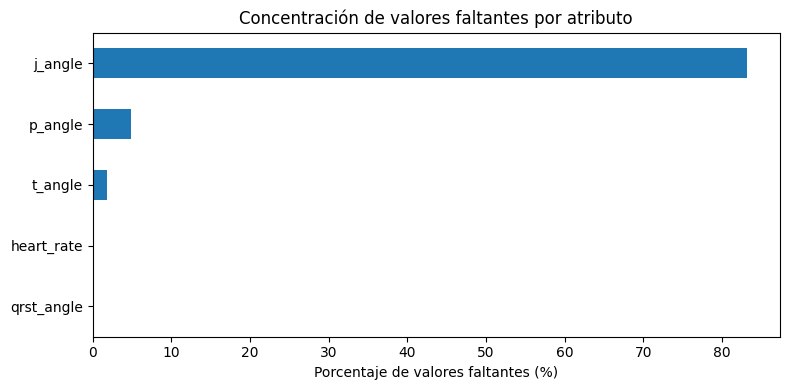

In [2]:
#cuenta los valores faltantes por columna
missing_count = X_raw.isna().sum()

#creacion del dataframe con el reporte de valores faltantes
missing_report = pd.DataFrame({
    "faltantes": missing_count[missing_count > 0],
    "porcentaje_%": 100 * missing_count[missing_count > 0] / len(X_raw)
}).sort_values("porcentaje_%", ascending=False)

#imprime el reporte de valores faltantes
display(missing_report.round(3))

#cuenta las filas con al menos un faltante
rows_any_missing = X_raw.isna().any(axis=1).sum()

#elimina la columna j_angle y cuenta las filas con al menos un faltante
rows_any_missing_without_j = X_raw.drop(columns=["j_angle"]).isna().any(axis=1).sum()

print(f"Filas con al menos un faltante: {rows_any_missing}/{len(X_raw)} "
      f"({100*rows_any_missing/len(X_raw):.2f}%)")
print(f"Filas con faltantes después de retirar j_angle: {rows_any_missing_without_j}/{len(X_raw)} "
      f"({100*rows_any_missing_without_j/len(X_raw):.2f}%)")

#impresion del grafico de concentracion de valores faltantes por atributo
plt.figure(figsize=(8, 4))
missing_report["porcentaje_%"].sort_values().plot(kind="barh")
plt.xlabel("Porcentaje de valores faltantes (%)")
plt.title("Concentración de valores faltantes por atributo")
plt.tight_layout()
plt.show()

### 2.2 Particionamiento estratificado sin `sklearn`

El dataset está desbalanceado y varias clases poseen muy pocos ejemplos. Un corte aleatorio simple podría dejar alguna clase pequeña completamente fuera de `Train`. Se implementa por ello un *split* estratificado manual con NumPy:

1. Se agrupan los índices por clase.
2. Se barajan con una semilla fija.
3. Se reserva aproximadamente el 20 % para prueba, conservando al menos una observación en `Train` cuando la clase tiene más de un registro.

**Regla de oro:** a partir de este punto, `Test` se considera información futura. No se utilizarán sus valores para ajustar parámetros de preprocesamiento.

In [ ]:
def stratified_split_numpy(X, y, test_size=0.20, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    y_arr = y.to_numpy()

    for clase in np.sort(y.unique()):
        idx = np.where(y_arr == clase)[0]
        rng.shuffle(idx)
        n_c = len(idx)

        if n_c <= 1:
            n_test = 0
        else:
            n_test = int(round(test_size * n_c))
            n_test = max(1, n_test)
            n_test = min(n_test, n_c - 1)

        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])

    train_idx = np.array(train_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return (
        X.iloc[train_idx].reset_index(drop=True),
        X.iloc[test_idx].reset_index(drop=True),
        y.iloc[train_idx].reset_index(drop=True),
        y.iloc[test_idx].reset_index(drop=True),
    )

X_train_raw, X_test_raw, y_train, y_test = stratified_split_numpy(X_raw, y_raw)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
print("\nDistribución de clases en Train:")
display(y_train.value_counts().sort_index().rename("n_train").to_frame())
print("Distribución de clases en Test:")
display(y_test.value_counts().sort_index().rename("n_test").to_frame())

X_train_raw: (360, 279)
X_test_raw : (92, 279)

Distribución de clases en Train:


,n_train
Clase,
1,196
2,35
3,12
4,12
5,10
6,20
7,2
8,1
9,7


Distribución de clases en Test:


,n_test
Clase,
1,49
2,9
3,3
4,3
5,3
6,5
7,1
8,1
9,2


## 4. C) Tratamiento de valores faltantes

> Se resuelve esta parte antes del análisis espectral porque `rank`, covarianzas, autovalores y distancias de Mahalanobis requieren una matriz numérica completa.

### 4.1 MCAR, MAR y MNAR: qué puede afirmarse con los datos

Sea $R_j=1$ si el atributo $X_j$ está ausente y $R_j=0$ si está observado.

- **MCAR:** $P(R_j=1\mid X_{obs},X_{miss})=P(R_j=1)$.
- **MAR:** $P(R_j=1\mid X_{obs},X_{miss})=P(R_j=1\mid X_{obs})$.
- **MNAR:** la ausencia depende del propio valor no observado, aun condicionando por $X_{obs}$.

Con una sola base observacional **no es posible demostrar MNAR** únicamente a partir de los datos disponibles, porque el valor que explicaría su ausencia no se observa. Sí podemos buscar evidencia contra MCAR: si el indicador de ausencia está asociado con variables observadas, MCAR deja de ser plausible y MAR se vuelve una hipótesis de trabajo razonable.

En `j_angle` la ausencia supera 80 %. Con tan pocas observaciones reales, una imputación multivariada de alta dimensión tendría una incertidumbre demasiado grande y podría crear estructura artificial. Por ello se elimina el atributo.

In [ ]:
# Diagnóstico de asociación entre el indicador de ausencia y variables observadas.
def missingness_association_report(X_train):
    rows = []
    complete_predictors = [
        c for c in X_train.columns
        if (not X_train[c].isna().any()) and X_train[c].nunique(dropna=True) > 1
    ]

    for target in X_train.columns[X_train.isna().any()]:
        R = X_train[target].isna().astype(float)
        correlations = []
        for c in complete_predictors:
            corr = R.corr(X_train[c])
            if pd.notna(corr):
                correlations.append((abs(corr), corr, c))

        if correlations:
            abs_corr, corr, predictor = max(correlations)
        else:
            abs_corr, corr, predictor = np.nan, np.nan, None

        rows.append({
            "atributo_faltante": target,
            "faltantes_train": int(R.sum()),
            "tasa_faltante_%": 100 * R.mean(),
            "predictor_observado_mas_asociado": predictor,
            "corr(R, predictor)": corr,
            "|corr|": abs_corr,
        })

    return pd.DataFrame(rows).sort_values("tasa_faltante_%", ascending=False)

assoc = missingness_association_report(X_train_raw)
display(assoc.round(4))

,atributo_faltante,faltantes_train,tasa_faltante_%,predictor_observado_mas_asociado,"corr(R, predictor)",|corr|
2,j_angle,301,83.6111,qrs_duration,-0.3933,0.3933
1,p_angle,18,5.0000,DII_P_amp,-0.4279,0.4279
0,t_angle,7,1.9444,DIII_diphasic_T,0.2601,0.2601
3,heart_rate,1,0.2778,V1_q_width,0.1487,0.1487


### 4.2 Decisión de conservación/eliminación

La estrategia será:

1. **Eliminar `j_angle`**: la tasa de ausencia es extrema. Imputarlo significaría que la mayor parte de la columna estaría generada por el algoritmo y no medida.
2. **No eliminar filas** por los faltantes restantes: después de retirar `j_angle`, solo una fracción pequeña de pacientes tiene valores ausentes. Eliminar esas observaciones desperdiciaría información de los otros 278 atributos y puede afectar clases minoritarias.
3. **Eliminar atributos constantes detectados exclusivamente en `Train`**: una columna de varianza cero no aporta información discriminante y hace singular la matriz de covarianza/Gram.
4. **Imputar `t_angle`, `p_angle`, `qrst_angle` y `heart_rate` mediante un algoritmo MICE básico propio**, usando solo información de `Train` para estimar sus parámetros.

Obsérvese que eliminar una variable por 83 % de ausencia es distinto de eliminar una observación completa: aquí se sacrifica una dimensión poco identificada para conservar 452 pacientes.

In [ ]:
# 1) Columna con ausencia extrema: criterio fijado en Train.
high_missing_threshold = 0.50
high_missing_cols = [
    c for c in X_train_raw.columns
    if X_train_raw[c].isna().mean() >= high_missing_threshold
]

print("Columnas eliminadas por ausencia >= 50% (ajustado en Train):")
print(high_missing_cols)

X_train_stage = X_train_raw.drop(columns=high_missing_cols).copy()
X_test_stage = X_test_raw.drop(columns=high_missing_cols).copy()

# 2) Columnas constantes/degeneradas detectadas SOLO con Train.
constant_cols = [
    c for c in X_train_stage.columns
    if X_train_stage[c].nunique(dropna=True) <= 1
]

print(f"\nColumnas constantes en Train eliminadas: {len(constant_cols)}")
print(constant_cols)

X_train_stage = X_train_stage.drop(columns=constant_cols).copy()
X_test_stage = X_test_stage.drop(columns=constant_cols).copy()

# Columnas originalmente susceptibles de faltar, salvo las descartadas.
# La lista de atributos con '?' es una propiedad del esquema/auditoría; los parámetros
# numéricos de imputación se ajustarán únicamente en Train.
cols_to_impute = [
    c for c in X_raw.columns
    if X_raw[c].isna().any()
    and c not in high_missing_cols
    and c not in constant_cols
]

print("\nColumnas a imputar:", cols_to_impute)
print("Faltantes en Train:")
print(X_train_stage[cols_to_impute].isna().sum())
print("Faltantes en Test:")
print(X_test_stage[cols_to_impute].isna().sum())

Columnas eliminadas por ausencia >= 50% (ajustado en Train):
['j_angle']

Columnas constantes en Train eliminadas: 22
['DI_s_prime_width', 'DII_ragged_P', 'DIII_ragged_R', 'DIII_ragged_P', 'AVL_s_prime_width', 'AVL_ragged_R', 'AVF_ragged_P', 'AVF_ragged_T', 'V4_ragged_P', 'V4_diphasic_P', 'V5_s_prime_width', 'V5_ragged_R', 'V5_ragged_P', 'V5_ragged_T', 'V6_s_prime_width', 'V6_diphasic_R', 'V6_diphasic_P', 'V6_ragged_T', 'DI_S_prime_amp', 'AVL_S_prime_amp', 'V5_S_prime_amp', 'V6_S_prime_amp']

Columnas a imputar: ['t_angle', 'p_angle', 'qrst_angle', 'heart_rate']
Faltantes en Train:
t_angle        7
p_angle       18
qrst_angle     0
heart_rate     1
dtype: int64
Faltantes en Test:
t_angle       1
p_angle       4
qrst_angle    1
heart_rate    0
dtype: int64


### 4.3 Demostración matemática de la trampa de la media y del colapso de varianza

Sean $x_1,\ldots,x_n$ los valores observados de una variable, con media

$$
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i,
$$

y supongamos que existen $m$ valores faltantes. Si todos se reemplazan por $\mu$, la nueva media sigue siendo $\mu$ porque

$$
\mu_{new}=\frac{\sum_{i=1}^{n}x_i+m\mu}{n+m}
=\frac{n\mu+m\mu}{n+m}=\mu.
$$

Sin embargo, los $m$ valores imputados aportan desviación cero respecto de la media. Usando la **varianza poblacional**,

$$
\sigma^2_{obs}=\frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2,
$$

se obtiene

$$
\begin{aligned}
\sigma^2_{new}
&=\frac{1}{n+m}
\left[
\sum_{i=1}^{n}(x_i-\mu)^2
+\sum_{k=1}^{m}(\mu-\mu)^2
\right]\\
&=\frac{1}{n+m}\sum_{i=1}^{n}(x_i-\mu)^2\\
&=\boxed{\frac{n}{n+m}\sigma^2_{obs}}.
\end{aligned}
$$

Como $n/(n+m)<1$ para $m>0$, la varianza disminuye necesariamente. Esta es la **trampa de la media**: preserva el primer momento, pero comprime el segundo momento y además debilita covarianzas con otras variables.

Si se utiliza la varianza muestral con divisor $n-1$, el factor exacto cambia a

$$
 s^2_{new}=\frac{n-1}{n+m-1}s^2_{obs},
$$

pero la conclusión es la misma: la dispersión colapsa.

In [ ]:
# Demostración empírica usando una variable con faltantes en Train.
var_demo = "p_angle"
observed = X_train_stage[var_demo].dropna().to_numpy(dtype=float)
n_obs = observed.size
m_miss = int(X_train_stage[var_demo].isna().sum())

mu_obs = observed.mean()
var_obs_pop = np.var(observed, ddof=0)

mean_imputed = X_train_stage[var_demo].fillna(mu_obs).to_numpy(dtype=float)
var_mean_imp_pop = np.var(mean_imputed, ddof=0)
var_formula = n_obs / (n_obs + m_miss) * var_obs_pop

print(f"Variable elegida: {var_demo}")
print(f"n observados = {n_obs}, m faltantes = {m_miss}")
print(f"Varianza observada               = {var_obs_pop:.6f}")
print(f"Varianza tras imputar con media  = {var_mean_imp_pop:.6f}")
print(f"Predicción n/(n+m)*var_obs       = {var_formula:.6f}")
print(f"Error numérico                   = {abs(var_mean_imp_pop-var_formula):.3e}")

Variable elegida: p_angle
n observados = 342, m faltantes = 18
Varianza observada               = 737.013893
Varianza tras imputar con media  = 700.163199
Predicción n/(n+m)*var_obs       = 700.163199
Error numérico                   = 1.137e-13


### 4.4 MICE básico propio con NumPy/Pandas

La imputación se trata como un problema predictivo multivariado. Para cada atributo incompleto $X_j$ se modela

$$
X_j \approx \beta_0 + \sum_{k\in S_j}\beta_k X_k,
$$

donde $S_j$ contiene los predictores más correlacionados con $X_j$ dentro de `Train`.

El procedimiento implementado es deliberadamente más cuidadoso que una imputación por media:

- Inicialización temporal con **mediana de Train** para poder arrancar las ecuaciones encadenadas.
- Selección de un número moderado de predictores correlacionados, evitando ajustar 250+ coeficientes con pocas observaciones.
- Estandarización interna de predictores y **Ridge pequeño** para evitar matrices singulares.
- Reestimación iterativa por cadenas, estilo MICE.
- Adición estocástica de residuos del modelo sobre los faltantes. Esto evita que todos los valores imputados caigan exactamente sobre la esperanza condicional y ayuda a preservar la variabilidad.
- Recorte al rango observado en `Train`, evitando extrapolaciones físicamente absurdas.

No se usa `sklearn`; el ajuste se realiza con álgebra lineal de NumPy.

In [ ]:
def _abs_corr(x, y):
    """Correlación absoluta, robusta al caso de varianza cero."""
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0
    return abs(np.corrcoef(x, y)[0, 1])


def fit_mice_numpy(
    X_train,
    target_cols,
    n_iter=8,
    top_k=12,
    ridge=1e-2,
    seed=123,
):
    """
    Ajusta e imputa un esquema MICE básico usando SOLO X_train.

    Devuelve:
        X_imputed_train : DataFrame completo.
        state           : parámetros necesarios para transformar Test.
    """
    rng = np.random.default_rng(seed)
    X0 = X_train.astype(float).copy()
    original_missing = X0.isna().copy()

    # Inicialización robusta: mediana de Train.
    medians = X0.median(axis=0)
    X_work = X0.fillna(medians)

    models = {}

    for _ in range(n_iter):
        for target in target_cols:
            if target not in X_work.columns:
                continue

            observed_mask = ~original_missing[target]
            y_obs = X0.loc[observed_mask, target].to_numpy(dtype=float)

            # Se requieren suficientes datos para un modelo multivariado razonable.
            if y_obs.size < max(10, top_k + 3):
                continue

            candidates = [
                c for c in X_work.columns
                if c != target and X_work.loc[observed_mask, c].std(ddof=0) > 1e-12
            ]

            scores = []
            for c in candidates:
                x_c = X_work.loc[observed_mask, c].to_numpy(dtype=float)
                scores.append((_abs_corr(x_c, y_obs), c))

            predictors = [c for _, c in sorted(scores, reverse=True)[:top_k]]

            A = X_work.loc[observed_mask, predictors].to_numpy(dtype=float)
            mu_x = A.mean(axis=0)
            sd_x = A.std(axis=0, ddof=0)
            sd_x = np.where(sd_x < 1e-12, 1.0, sd_x)
            Z = (A - mu_x) / sd_x

            y_mean = y_obs.mean()
            y_centered = y_obs - y_mean

            # Ridge: (Z^T Z + lambda I) beta = Z^T y
            gram = Z.T @ Z + ridge * np.eye(Z.shape[1])
            beta = np.linalg.solve(gram, Z.T @ y_centered)

            fitted = y_mean + Z @ beta
            residuals = y_obs - fitted
            lo, hi = y_obs.min(), y_obs.max()

            models[target] = {
                "predictors": predictors,
                "mu_x": mu_x,
                "sd_x": sd_x,
                "y_mean": y_mean,
                "beta": beta,
                "residuals": residuals.copy(),
                "lo": lo,
                "hi": hi,
            }

            # Reimputación encadenada SOLO donde originalmente faltaba en Train.
            missing_mask = original_missing[target]
            if missing_mask.any():
                A_miss = X_work.loc[missing_mask, predictors].to_numpy(dtype=float)
                Z_miss = (A_miss - mu_x) / sd_x
                pred = y_mean + Z_miss @ beta

                # Imputación estocástica: preserva incertidumbre/varianza mejor que la media.
                if residuals.size > 0:
                    pred = pred + rng.choice(residuals, size=pred.size, replace=True)

                pred = np.clip(pred, lo, hi)
                X_work.loc[missing_mask, target] = pred

    state = {
        "medians": medians,
        "models": models,
        "target_cols": list(target_cols),
        "n_iter": n_iter,
    }
    return X_work, state


def transform_mice_numpy(X_new, state, n_iter=4, seed=321):
    """Transforma datos nuevos usando exclusivamente parámetros aprendidos en Train."""
    rng = np.random.default_rng(seed)
    X_new = X_new.astype(float).copy()
    original_missing = X_new.isna().copy()

    # Importante: se usan medianas de TRAIN, no medianas de Test.
    X_work = X_new.fillna(state["medians"])

    for _ in range(n_iter):
        for target, model in state["models"].items():
            if target not in X_work.columns:
                continue

            missing_mask = original_missing[target]
            if not missing_mask.any():
                continue

            predictors = model["predictors"]
            A = X_work.loc[missing_mask, predictors].to_numpy(dtype=float)
            Z = (A - model["mu_x"]) / model["sd_x"]
            pred = model["y_mean"] + Z @ model["beta"]

            residuals = model["residuals"]
            if residuals.size > 0:
                pred = pred + rng.choice(residuals, size=pred.size, replace=True)

            pred = np.clip(pred, model["lo"], model["hi"])
            X_work.loc[missing_mask, target] = pred

    return X_work


X_train_imp, mice_state = fit_mice_numpy(X_train_stage, cols_to_impute)
X_test_imp = transform_mice_numpy(X_test_stage, mice_state)

print("Faltantes finales en Train:", int(X_train_imp.isna().sum().sum()))
print("Faltantes finales en Test :", int(X_test_imp.isna().sum().sum()))
print("Dimensión final de Train  :", X_train_imp.shape)
print("Dimensión final de Test   :", X_test_imp.shape)

Faltantes finales en Train: 0
Faltantes finales en Test : 0
Dimensión final de Train  : (360, 256)
Dimensión final de Test   : (92, 256)


### 4.5 Verificación: media vs. MICE

No se exige que MICE reproduzca exactamente la varianza original —los valores reales faltantes son desconocidos—, pero sí queremos evitar el colapso determinista provocado por reemplazar todos los faltantes por una única constante.

La siguiente tabla compara, para cada atributo incompleto:

- varianza de los valores realmente observados en `Train`;
- varianza después de imputar por media;
- varianza después del MICE implementado.

Una imputación razonable debe interpretarse como una reconstrucción con incertidumbre, no como creación de observaciones idénticas en el centro de la distribución.

In [ ]:
variance_comparison = []
for c in cols_to_impute:
    observed = X_train_stage[c].dropna().to_numpy(dtype=float)
    mean_value = X_train_stage[c].mean()
    mean_imp = X_train_stage[c].fillna(mean_value).to_numpy(dtype=float)
    mice_imp = X_train_imp[c].to_numpy(dtype=float)

    variance_comparison.append({
        "atributo": c,
        "faltantes_train": int(X_train_stage[c].isna().sum()),
        "var_observada": np.var(observed, ddof=0),
        "var_media": np.var(mean_imp, ddof=0),
        "var_MICE": np.var(mice_imp, ddof=0),
    })

display(pd.DataFrame(variance_comparison).round(5))

,atributo,faltantes_train,var_observada,var_media,var_MICE
0,t_angle,7,3077.07016,3017.23824,3110.15699
1,p_angle,18,737.01389,700.16320,757.61192
2,qrst_angle,0,1340.48182,1340.48182,1340.48182
3,heart_rate,1,206.03308,205.46077,205.53217


## 3. A) Análisis estructural y estabilidad numérica

Ahora sí se dispone de una matriz completa

$$
D=X_{train}\in\mathbb{R}^{n\times d}.
$$

Se evaluarán:

- $\operatorname{rank}(D)$;
- espectro de la matriz de covarianza;
- número de condición de $D^TD$.

Si $\operatorname{rank}(D)<d$, existe dependencia lineal exacta y $D^TD$ es singular en aritmética exacta. Si el rango es completo pero $\kappa(D^TD)$ es enorme, existe multicolinealidad cercana e inestabilidad numérica.

D ∈ R^(360 x 256)
rank(D) = 250
Deficiencia de rango d-rank(D) = 6
rank(Sigma) = 250
kappa(D^T D) = 2.123434e+23
Autovalor mínimo de Sigma = -1.212389e-14
Autovalor máximo de Sigma = 6.506545e+03
Autovalores numéricamente ~0 (<1e-10): 6


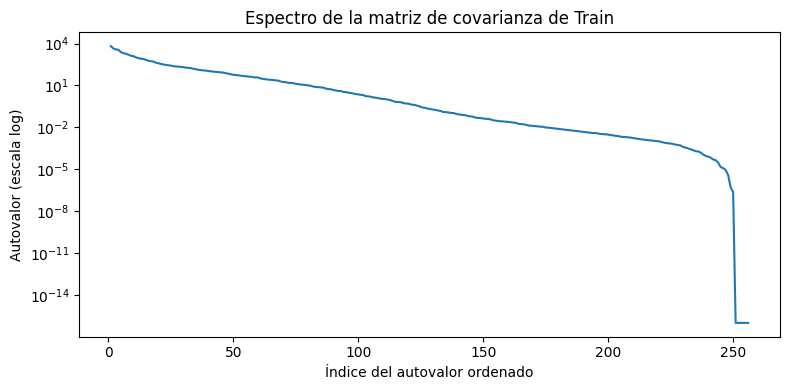

In [ ]:
D = X_train_imp.to_numpy(dtype=float)
n_train, d_train = D.shape

rank_D = np.linalg.matrix_rank(D)
Gram = D.T @ D
cond_Gram = np.linalg.cond(Gram)

mu_train_rawscale = D.mean(axis=0)
D_centered = D - mu_train_rawscale
Sigma = (D_centered.T @ D_centered) / (n_train - 1)
eigenvalues = np.linalg.eigvalsh(Sigma)
rank_Sigma = np.linalg.matrix_rank(Sigma)

print(f"D ∈ R^({n_train} x {d_train})")
print(f"rank(D) = {rank_D}")
print(f"Deficiencia de rango d-rank(D) = {d_train-rank_D}")
print(f"rank(Sigma) = {rank_Sigma}")
print(f"kappa(D^T D) = {cond_Gram:.6e}")
print(f"Autovalor mínimo de Sigma = {eigenvalues.min():.6e}")
print(f"Autovalor máximo de Sigma = {eigenvalues.max():.6e}")
print(f"Autovalores numéricamente ~0 (<1e-10): {(eigenvalues < 1e-10).sum()}")

plt.figure(figsize=(8, 4))
positive_eigs = np.clip(eigenvalues, 1e-16, None)
plt.semilogy(np.arange(1, d_train + 1), positive_eigs[::-1])
plt.xlabel("Índice del autovalor ordenado")
plt.ylabel("Autovalor (escala log)")
plt.title("Espectro de la matriz de covarianza de Train")
plt.tight_layout()
plt.show()

### Interpretación del análisis espectral

Un número de condición muy grande significa que pequeñas perturbaciones en los datos pueden producir variaciones grandes en soluciones basadas en $(X^TX)^{-1}$. Además, una deficiencia de rango confirma que la estandarización por sí sola **no puede** arreglar dependencias lineales exactas. Por eso, en etapas posteriores se usa pseudoinversa o regularización de Tikhonov/Ridge cuando se necesita invertir una matriz de covarianza.

## 5. E) Transformaciones espaciales

### 5.1 Mean Centering e invarianza traslacional

Sea

$$
Z=X-\mathbf{1}\mu^T,
\qquad
\mu=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

La covarianza no cambia si trasladamos todos los puntos por el mismo vector $a$:

$$
\operatorname{Cov}(X+a)
=E[(X+a-E[X+a])(X+a-E[X+a])^T]
=\operatorname{Cov}(X).
$$

Por tanto,

$$
\operatorname{tr}(\Sigma_{X+a})=\operatorname{tr}(\Sigma_X).
$$

El rastro representa la suma de las varianzas marginales, es decir, la dispersión total a lo largo de los ejes coordenados.

In [ ]:
# Parámetros ajustados SOLO con Train.
mu_train = X_train_imp.mean(axis=0)
sigma_train = X_train_imp.std(axis=0, ddof=0)

# Ya se eliminaron columnas constantes, pero mantenemos protección numérica.
sigma_train_safe = sigma_train.mask(sigma_train < 1e-12, 1.0)

X_train_centered = X_train_imp - mu_train
X_test_centered = X_test_imp - mu_train

X_train_z = X_train_centered / sigma_train_safe
X_test_z = X_test_centered / sigma_train_safe

# Verificación de media cero en Train.
max_abs_mean_centered = np.abs(X_train_centered.mean(axis=0)).max()
max_abs_mean_z = np.abs(X_train_z.mean(axis=0)).max()

Sigma_before = np.cov(X_train_imp.to_numpy(), rowvar=False, ddof=1)
Sigma_after_center = np.cov(X_train_centered.to_numpy(), rowvar=False, ddof=1)

trace_before = np.trace(Sigma_before)
trace_after = np.trace(Sigma_after_center)

print(f"max |media| después de centrar Train = {max_abs_mean_centered:.3e}")
print(f"max |media| después de Z-score       = {max_abs_mean_z:.3e}")
print(f"tr(Sigma antes)   = {trace_before:.12f}")
print(f"tr(Sigma centrada)= {trace_after:.12f}")
print(f"Diferencia absoluta= {abs(trace_before-trace_after):.3e}")

max |media| después de centrar Train = 1.066e-14
max |media| después de Z-score       = 4.404e-16
tr(Sigma antes)   = 41626.101754400494
tr(Sigma centrada)= 41626.101754400494
Diferencia absoluta= 0.000e+00


### 5.2 Estandarización y condicionamiento

La estandarización

$$
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

elimina la dominancia artificial producida por unidades heterogéneas. Sin embargo, si existen dependencias lineales exactas, el Hessiano $H=X^TX/n$ puede seguir siendo singular. En ese caso Ridge reemplaza

$$
H \longmapsto H_\lambda=H+\lambda I,
$$

y desplaza todos los autovalores: $\lambda_i(H_\lambda)=\lambda_i(H)+\lambda>0$.

In [ ]:
Z_train = X_train_z.to_numpy(dtype=float)
H_z = (Z_train.T @ Z_train) / len(Z_train)
cond_H_z = np.linalg.cond(H_z)

lambda_ridge = 1e-2 * np.trace(H_z) / H_z.shape[0]
H_ridge = H_z + lambda_ridge * np.eye(H_z.shape[0])
cond_H_ridge = np.linalg.cond(H_ridge)

print(f"kappa(H estandarizado)       = {cond_H_z:.6e}")
print(f"lambda Ridge                 = {lambda_ridge:.6e}")
print(f"kappa(H + lambda I)          = {cond_H_ridge:.6e}")

kappa(H estandarizado)       = 3.712379e+17
lambda Ridge                 = 1.000000e-02
kappa(H + lambda I)          = 2.027809e+03


## 5. B) Detección multivariada de ruido con Mahalanobis

Para cada observación estandarizada se calcula

$$
D_M(x)=\sqrt{(x-\mu)^T\Sigma^{-1}(x-\mu)}.
$$

Como la covarianza de este dataset conserva algunas dependencias lineales, usar una inversa ordinaria sería numéricamente inestable. Se utiliza una covarianza regularizada

$$
\Sigma_\lambda=\Sigma+\lambda I
$$

y su pseudoinversa. Esto no cambia la definición conceptual de Mahalanobis; es una estabilización necesaria para este conjunto de alta dimensión.

Bajo normalidad multivariada ideal, $D_M^2$ se aproxima a una $\chi^2_d$. Como criterio tipo $3\sigma$ se usa la aproximación

$$
D_M^2 > d+3\sqrt{2d}.
$$

Los registros detectados se **marcan para revisión**, no se eliminan automáticamente: en medicina, un valor extremo puede ser precisamente el patrón clínico que interesa clasificar.

Dimensión d = 256
Umbral aproximado de Mahalanobis = 17.99673
Registros marcados = 69 de 360


,indice_train,Clase,Mahalanobis,outlier_3sigma_aprox
209,209,5,18.91703,True
107,107,1,18.91640,True
118,118,1,18.91624,True
97,97,10,18.91426,True
268,268,1,18.91228,True
50,50,1,18.91208,True
101,101,3,18.91173,True
184,184,9,18.91164,True
144,144,2,18.91158,True
9,9,1,18.91157,True


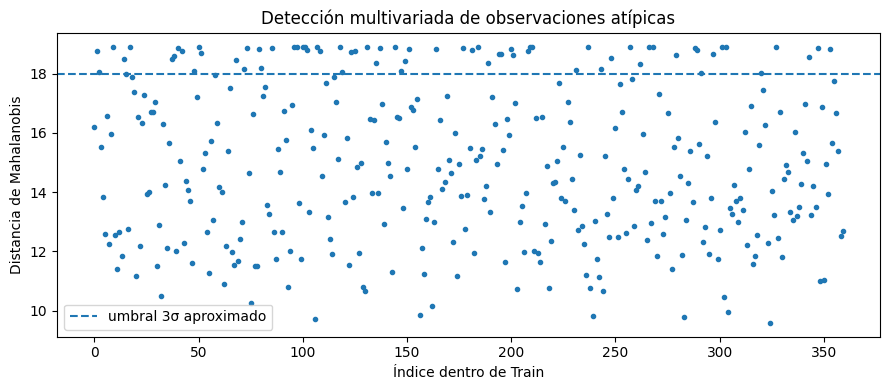

In [ ]:
Sigma_z = np.cov(Z_train, rowvar=False, ddof=1)
d = Sigma_z.shape[0]

lambda_cov = 1e-3 * np.trace(Sigma_z) / d
Sigma_reg = Sigma_z + lambda_cov * np.eye(d)
Sigma_inv = np.linalg.pinv(Sigma_reg, rcond=1e-10)

mu_z = Z_train.mean(axis=0)
delta = Z_train - mu_z
DM2 = np.einsum("ij,jk,ik->i", delta, Sigma_inv, delta)
DM = np.sqrt(np.maximum(DM2, 0.0))

threshold2 = d + 3 * np.sqrt(2 * d)
threshold_DM = np.sqrt(threshold2)
outlier_mask = DM > threshold_DM
outlier_idx = np.where(outlier_mask)[0]

outlier_table = pd.DataFrame({
    "indice_train": np.arange(len(DM)),
    "Clase": y_train.to_numpy(),
    "Mahalanobis": DM,
    "outlier_3sigma_aprox": outlier_mask,
}).sort_values("Mahalanobis", ascending=False)

print(f"Dimensión d = {d}")
print(f"Umbral aproximado de Mahalanobis = {threshold_DM:.5f}")
print(f"Registros marcados = {outlier_mask.sum()} de {len(DM)}")
display(outlier_table.head(20).round(5))

plt.figure(figsize=(9, 4))
plt.plot(np.arange(len(DM)), DM, ".")
plt.axhline(threshold_DM, linestyle="--", label="umbral 3σ aproximado")
plt.xlabel("Índice dentro de Train")
plt.ylabel("Distancia de Mahalanobis")
plt.title("Detección multivariada de observaciones atípicas")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de los outliers

El número de candidatos puede ser mayor que el 0.27 % esperado bajo una normal multivariada ideal. Eso no implica que el código esté mal: el dataset Arrhythmia mezcla múltiples clases clínicas, variables binarias y continuas, fuerte correlación y distribuciones no gaussianas. Por tanto, el umbral $\chi^2/3\sigma$ debe interpretarse como un **filtro diagnóstico**, no como una regla automática de borrado.

Eliminar estos pacientes podría borrar precisamente arritmias poco frecuentes. La decisión prudente es conservarlos y, si el objetivo posterior lo exige, estudiar su influencia por clase y con métodos robustos.

## 6. F) Análisis crítico de estabilidad

El flujo aplicado respeta una separación estricta entre entrenamiento y prueba. El conjunto `Test` no intervino en el cálculo de medianas iniciales, modelos MICE, selección de columnas constantes, medias, desviaciones estándar, covarianzas ni regularizaciones. En consecuencia, las transformaciones aplicadas a `Test` simulan correctamente lo que ocurriría con observaciones nuevas y evitan optimismo artificial por *data leakage*.

La imputación por media fue descartada como estrategia principal porque, aunque conserva la media, reduce determinísticamente la varianza por el factor $n/(n+m)$ y atenúa la covarianza. En una tarea de clasificación esto puede estrechar artificialmente la nube de datos y generar una falsa sensación de confianza. El MICE básico implementado aprovecha dependencias entre variables y añade un término residual estocástico, por lo que no obliga a todas las observaciones faltantes a coincidir en un único punto central.

También se eliminó `j_angle` porque su ausencia es tan alta que cualquier reconstrucción estaría dominada por valores sintéticos. En este caso, conservar la columna sería más riesgoso que perder una dimensión. En cambio, eliminar todas las filas incompletas habría descartado la mayoría de los pacientes, por lo que no resulta defendible.

Desde el punto de vista algebraico, centrar los datos no modifica la covarianza ni su rastro; solo traslada el origen al centro de gravedad. La estandarización sí modifica las escalas y reduce la anisotropía debida a unidades heterogéneas, de modo que las curvas de nivel de funciones cuadráticas tienden a ser menos elongadas. Esto permite que un método de descenso de gradiente use pasos más homogéneos entre coordenadas.

No obstante, la estandarización no elimina dependencias lineales exactas. El análisis de rango muestra que todavía pueden existir direcciones degeneradas, por lo cual $X^TX$ o $\Sigma$ pueden seguir siendo singulares o casi singulares. La regularización de Tikhonov/Ridge, $H_\lambda=H+\lambda I$, desplaza el espectro y reduce fuertemente el número de condición, estabilizando tanto la inversión matricial como la dinámica de optimización.

Finalmente, la distancia de Mahalanobis se calculó sobre el espacio estandarizado y con covarianza regularizada. Los puntos extremos se marcaron, pero no se eliminaron automáticamente, porque en un problema clínico multiclase una observación alejada puede contener señal diagnóstica real y no ruido.

## 7. Resumen de decisiones de preprocesamiento

| Problema | Decisión | Justificación |
|---|---|---|
| `j_angle` con ausencia extrema | Eliminar atributo | La mayor parte de la columna tendría que ser inventada; alta incertidumbre y riesgo de covarianza artificial. |
| Faltantes escasos en otros 4 atributos | Imputación multivariada iterativa | Aprovecha relaciones con otras variables y evita una constante central. |
| Imputación por media | Solo demostración, no estrategia final | Conserva media pero colapsa varianza y atenúa covarianza. |
| Filas incompletas | No eliminación masiva | Se perdería una fracción excesiva de pacientes y podrían desaparecer clases minoritarias. |
| Columnas constantes en Train | Eliminar | Varianza cero, información marginal nula y contribución a singularidad. |
| Estandarización | Ajustar en Train y aplicar a Test | Evita dominancia por escala y *data leakage*. |
| Covarianza singular/casi singular | Regularización/pseudoinversa | Mejora estabilidad numérica. |
| Outliers Mahalanobis | Marcar, no borrar automáticamente | En datos clínicos, extremos pueden ser casos reales de arritmia. |

Con esto quedan construidos `X_train_imp`, `X_test_imp`, `X_train_z` y `X_test_z`, listos para las etapas posteriores de modelado sin haber utilizado información estadística del conjunto de prueba durante el ajuste del preprocesamiento.